In [2]:
#IMPORTING LIBRARIES


import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from datetime import timedelta

In [3]:
#THE MISTAKE I MAFE IS WRONG DEFINIG OF THE DATA
# orders = pd.read_csv("/content/sample_data/olist_order_items_dataset.csv")
# customers = pd.read_csv("/content/sample_data/olist_customers_dataset.csv")
# customergeolocation = pd.read_csv("/content/sample_data/olist_geolocation_dataset.csv")
# orderpayments = pd.read_csv("/content/sample_data/olist_order_payments_dataset.csv")
# orderreviews = pd.read_csv("/content/sample_data/olist_order_reviews_dataset.csv")
# products = pd.read_csv("/content/sample_data/olist_products_dataset.csv")
# sellers = pd.read_csv("/content/sample_data/olist_sellers_dataset.csv")
# orders = pd.read_csv("/content/sample_data/olist_orders_dataset.csv")
# product_category_name_translation = pd.read_csv("/content/sample_data/product_category_name_translation.csv")

In [4]:
#MOUNTING DRIVE

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
#GIVING PATH / DIRECTORY
import os

base_path = "/content/drive/MyDrive/archive (3)"

In [6]:
# IMPORTING ALL DATA

import pandas as pd

orders = pd.read_csv(os.path.join(base_path, "olist_orders_dataset.csv"))
order_items = pd.read_csv(os.path.join(base_path, "olist_order_items_dataset.csv"))
customers = pd.read_csv(os.path.join(base_path, "olist_customers_dataset.csv"))
payments = pd.read_csv(os.path.join(base_path, "olist_order_payments_dataset.csv"))
reviews = pd.read_csv(os.path.join(base_path, "olist_order_reviews_dataset.csv"))
products = pd.read_csv(os.path.join(base_path, "olist_products_dataset.csv"))
sellers = pd.read_csv(os.path.join(base_path, "olist_sellers_dataset.csv"))
geolocation = pd.read_csv(os.path.join(base_path, "olist_geolocation_dataset.csv"))
category_translation = pd.read_csv(os.path.join(base_path, "product_category_name_translation.csv"))

In [7]:
# DATA SHAPE

for name, df in {
    "orders": orders,
    "order_items": order_items,
    "customers": customers,
    "payments": payments,
    "reviews": reviews
}.items():
    print(name, df.shape)

orders (99441, 8)
order_items (112650, 7)
customers (99441, 5)
payments (103886, 5)
reviews (99224, 7)


requirements = EDA HYPOTHESIS TESTING ACTIONABLES FURTHER EXPLORATION

ANALYSIS TO DOS UNDERSTAND CUSTOMER BEHAVIOUR VALIDATE ATTERNS STATISTICALLY BUSINESS RECOMMNEDATIONS FUTURE BUSINESS QUESTIONS

In [8]:
# MERGIGNG CUSTOMER ID TO ORDERS
df_main = orders.merge(customers, on="customer_id", how="left")

In [9]:
#MERGING REVIEWS TO ORDER ID
df_main = df_main.merge(reviews, on="order_id", how="left")

In [10]:
# MERGING PAYMENTS TO ORDER ID
df_main = df_main.merge(payments, on="order_id", how="left")

In [11]:
df_main.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,1.0,credit_card,3.0,179.12


In [12]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104478 entries, 0 to 104477
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       104478 non-null  object 
 1   customer_id                    104478 non-null  object 
 2   order_status                   104478 non-null  object 
 3   order_purchase_timestamp       104478 non-null  object 
 4   order_approved_at              104302 non-null  object 
 5   order_delivered_carrier_date   102580 non-null  object 
 6   order_delivered_customer_date  101324 non-null  object 
 7   order_estimated_delivery_date  104478 non-null  object 
 8   customer_unique_id             104478 non-null  object 
 9   customer_zip_code_prefix       104478 non-null  int64  
 10  customer_city                  104478 non-null  object 
 11  customer_state                 104478 non-null  object 
 12  review_id                     

In [13]:
#MERGING PRODUCT ID TO ORDERS
df_products = order_items.merge(products, on="product_id", how="left")

In [14]:
#MERGING SELLER ID TO PRODUCTS
df_products = df_products.merge(sellers, on="seller_id", how="left")

In [15]:
df_products = df_products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

In [16]:
df_products.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,27277,volta redonda,SP,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,3471,sao paulo,SP,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,37564,borda da mata,MG,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,14403,franca,SP,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,87900,loanda,PR,garden_tools


In [17]:
#CONVERT DATES
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    df_main[col] = pd.to_datetime(df_main[col])

In [18]:
# Create Delivery Delay
df_main["delivery_delay"] = (
    df_main["order_delivered_customer_date"]
    - df_main["order_estimated_delivery_date"]
).dt.days

In [19]:
# Create Purchase Month
df_main["purchase_month"] = (
    df_main["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [20]:
# ORDER TREND OVER TIME
df_main.groupby("purchase_month")["order_id"].count()

,order_id
purchase_month,
2016-09,4
2016-10,344
2016-12,1
2017-01,864
2017-02,1894
2017-03,2852
2017-04,2578
2017-05,3984
2017-06,3473


ORDER LESS 2016 9 12 2018 09 10
IN OTHER MONTH SALES ARE ABOVE  

In [21]:
# Review score distribution
df_main["review_score"].value_counts()

,count
review_score,
5.0,59822
4.0,20008
1.0,11975
3.0,8543
2.0,3330


3330 + 11975 IS THE TARGETED CUSTOMERS WE NEED TO IMPROVE OUR SERVICE AND GET 5TAR RATING

In [22]:
# Delivery delay vs Review
df_main.groupby("review_score")["delivery_delay"].mean()

,delivery_delay
review_score,
1.0,-4.114100
2.0,-8.660847
3.0,-10.833915
4.0,-12.374849
5.0,-13.406779


In [23]:
# PAYMENT TYPES
df_main["payment_type"].value_counts()

,count
payment_type,
credit_card,77198
boleto,19910
voucher,5830
debit_card,1536
not_defined,3


In [24]:
# Average spend by payment type
df_main.groupby("payment_type")["payment_value"].mean()

,payment_value
payment_type,
boleto,144.986413
credit_card,163.140977
debit_card,142.396569
not_defined,0.000000
voucher,65.499655


In [25]:
df_main = orders.merge(customers, on="customer_id", how="left")

df_main = df_main.merge(payments, on="order_id", how="left")

df_main = df_main.merge(reviews, on="order_id", how="left")

In [26]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    df_main[col] = pd.to_datetime(df_main[col])

df_main["delivery_delay"] = (
    df_main["order_delivered_customer_date"]
    - df_main["order_estimated_delivery_date"]
).dt.days

df_main.groupby("review_score")["delivery_delay"].mean()

,delivery_delay
review_score,
1.0,-4.114100
2.0,-8.660847
3.0,-10.833915
4.0,-12.374849
5.0,-13.406779


In [27]:
df_main.groupby("payment_type")["payment_value"].mean()

,payment_value
payment_type,
boleto,144.986413
credit_card,163.140977
debit_card,142.396569
not_defined,0.000000
voucher,65.499655


In [28]:
payment_counts = df_main["payment_type"].value_counts()

In [29]:
df_main.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp', 'delivery_delay'],
      dtype='object')

In [30]:
"payment_type" in df_main.columns

True

In [31]:
df_main = orders.merge(customers, on="customer_id", how="left")
df_main = df_main.merge(payments, on="order_id", how="left")
df_main = df_main.merge(reviews, on="order_id", how="left")

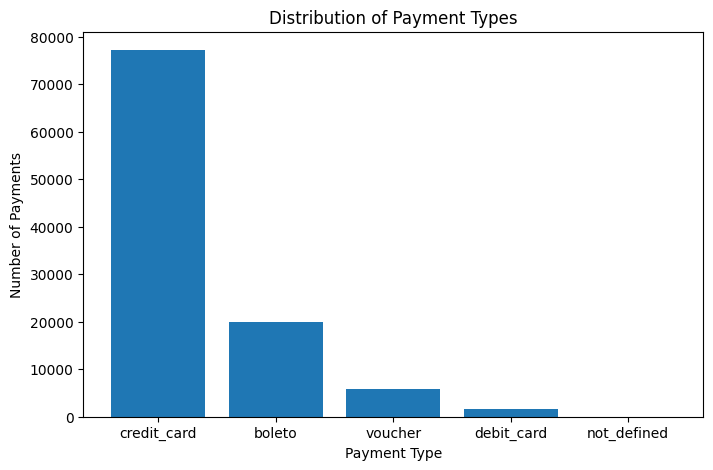

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

payment_counts = df_main["payment_type"].value_counts()

plt.bar(payment_counts.index, payment_counts.values)

plt.xlabel("Payment Type")
plt.ylabel("Number of Payments")
plt.title("Distribution of Payment Types")

plt.show()

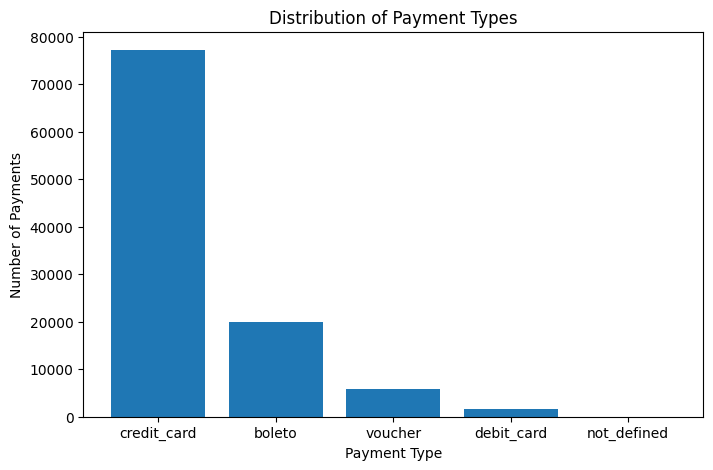

In [33]:
#Payment type distribution bar chart
plt.figure(figsize=(8, 5))
payment_counts = df_main["payment_type"].value_counts()
plt.bar(payment_counts.index, payment_counts.values)
plt.xlabel("Payment Type")
plt.ylabel("Number of Payments")
plt.title("Distribution of Payment Types")
plt.savefig("paymenttypes.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:

df_main = orders.merge(customers, on="customer_id", how="left")


You wrote:

“3330 + 11975 IS THE TARGETED CUSTOMERS WE NEED TO IMPROVE OUR SERVICE”

The idea is correct, but wording sounds informal and unclear.

Improvement

Write professionally:

Customers providing low review scores represent a key opportunity area for improving customer experience and retention.

You thought negative delivery delay was wrong.

Actually:

positive delay = delivered late
negative delay = delivered early
Improvement

Interpret business meaning instead of assuming it is an error.

Professional wording:

Negative delivery delay values indicate orders delivered earlier than estimated dates.

You observed lower orders in some months and assumed sales were low.

But:

dataset starts in 2016
dataset ends in 2018

So first and last months may be incomplete.

Improvement

Always check:

business logic
dataset coverage
time period completeness

Professional interpretation:

Lower order volumes in initial and final months are likely due to incomplete dataset coverage.

 Focusing More on Code Than Business Meaning

Right now you are thinking:

merge
syntax
values

But assignment mainly wants:

customer behavior
business insights
recommendations
growth thinking
Improvement

After every analysis ask:

Why does this happen?
What business problem does this indicate?
What should leadership do?

 Not Structuring Findings Properly

You are observing many things, but not organizing them.

Improvement

Use this structure:

Observation

What you found.

Business Meaning

Why it matters.

Actionable

What company should do.

In [35]:
# “what code should I run?”

In [36]:
#“what business problem am I solving?”

In [37]:
df_main.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0
customer_unique_id,0
customer_zip_code_prefix,0


In [38]:
df_main.shape

(99441, 12)

In [39]:
df_main.duplicated().sum()

np.int64(0)

In [40]:
df_main = df_main.merge(reviews, on="order_id", how="left")
df_main = df_main.merge(payments, on="order_id", how="left")

print("Total Orders:", df_main["order_id"].nunique())
print("Total Customers:", df_main["customer_unique_id"].nunique())
print("Average Review Score:", df_main["review_score"].mean())
print("Average Payment Value:", df_main["payment_value"].mean())

Total Orders: 99441
Total Customers: 96096
Average Review Score: 4.083855784255097
Average Payment Value: 153.92307148941873


In [41]:
import matplotlib.pyplot as plt

In [42]:
df_main["review_score"].value_counts().sort_index()

,count
review_score,
1.0,11975
2.0,3330
3.0,8543
4.0,20008
5.0,59822


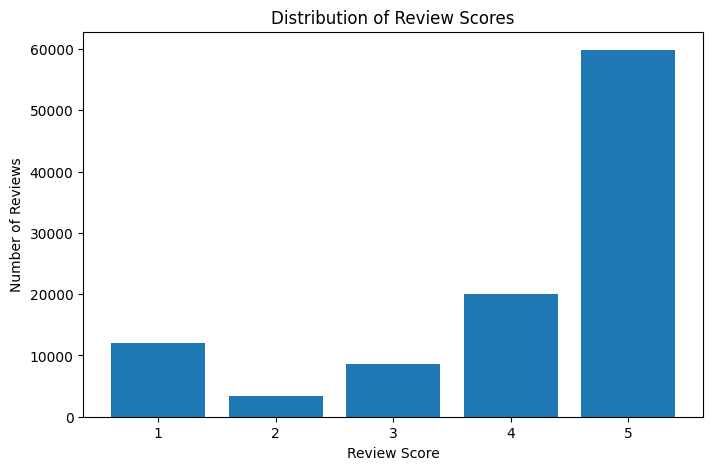

In [43]:
plt.figure(figsize=(8, 5))
review_counts = df_main["review_score"].value_counts().sort_index()
plt.bar(review_counts.index, review_counts.values)
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Scores")
plt.xticks(review_counts.index) # Ensure all review scores are shown on x-axis
plt.savefig("reviewscore.png", dpi=300, bbox_inches="tight")
plt.show()

In [44]:
df_main['order_purchase_timestamp'] = pd.to_datetime(df_main['order_purchase_timestamp'])
df_main['purchase_month'] = df_main['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = df_main.groupby('purchase_month')['order_id'].nunique()

In [64]:
fig = px.line(x=monthly_orders.index.astype(str), y=monthly_orders.values, labels={'x':'Month', 'y':'Number of Orders'})
fig.update_layout(title_text='Monthly Orders Over Time')
plt.savefig("monthlyordersovertime1.png", dpi=300, bbox_inches="tight")
fig.show()


<Figure size 640x480 with 0 Axes>

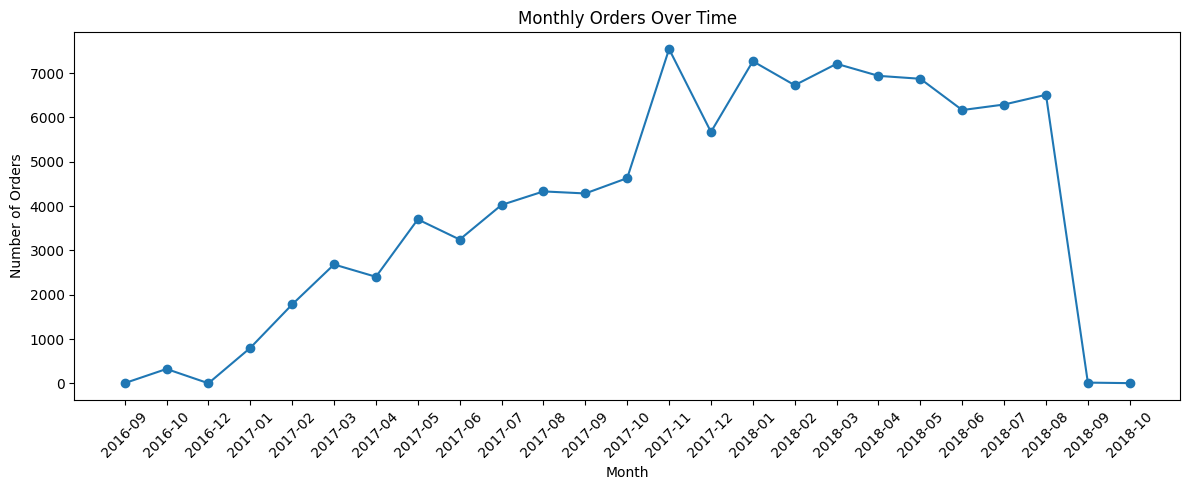

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    monthly_orders.index.astype(str),
    monthly_orders.values,
    marker='o'
)

plt.xticks(rotation=45)

plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.title("Monthly Orders Over Time")

plt.tight_layout()

# SAVE IMAGE
plt.savefig(
    "monthly_orders_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [63]:
import plotly.express as px

!pip install -U kaleido

fig = px.line(
    x=monthly_orders.index.astype(str),
    y=monthly_orders.values,
    labels={'x':'Month', 'y':'Number of Orders'}
)

fig.update_layout(title_text='Monthly Orders Over Time')

# ✅ SAVE IMAGE
fig.write_image("monthlyordersovertime11.png")

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


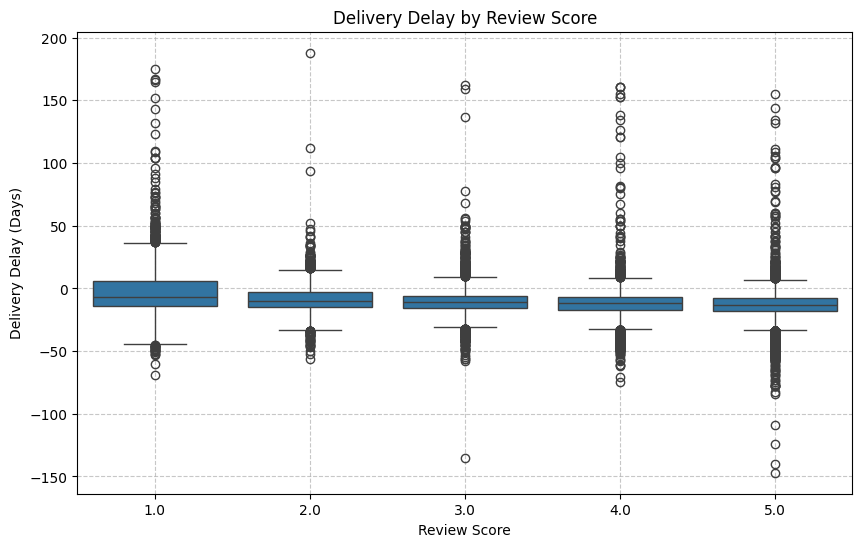

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    df_main[col] = pd.to_datetime(df_main[col], errors='coerce') # Use errors='coerce' to handle any parsing issues

df_main["delivery_delay"] = (
    df_main["order_delivered_customer_date"]
    - df_main["order_estimated_delivery_date"]
).dt.days

plt.figure(figsize=(10, 6))
sns.boxplot(x="review_score", y="delivery_delay", data=df_main)
plt.title('Delivery Delay by Review Score')
plt.xlabel('Review Score')
plt.ylabel('Delivery Delay (Days)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("delivery delay by review score.png", dpi=300, bbox_inches="tight")
plt.show()

In [47]:
df_products["product_category_name"].value_counts().head(10)

,count
product_category_name,
cama_mesa_banho,11115
beleza_saude,9670
esporte_lazer,8641
moveis_decoracao,8334
informatica_acessorios,7827
utilidades_domesticas,6964
relogios_presentes,5991
telefonia,4545
ferramentas_jardim,4347


In [48]:
df_products["product_category_name_english"].value_counts().head(10)

,count
product_category_name_english,
bed_bath_table,11115
health_beauty,9670
sports_leisure,8641
furniture_decor,8334
computers_accessories,7827
housewares,6964
watches_gifts,5991
telephony,4545
garden_tools,4347


In [49]:
df_full = df_products.merge(reviews, on="order_id", how="left")

df_full.groupby("product_category_name_english")["review_score"].mean().sort_values().head(10)

,review_score
product_category_name_english,
security_and_services,2.500000
diapers_and_hygiene,3.256410
office_furniture,3.493183
home_comfort_2,3.629630
fashion_male_clothing,3.641221
fixed_telephony,3.683206
party_supplies,3.767442
fashio_female_clothing,3.780000
furniture_mattress_and_upholstery,3.815789


In [50]:
df_full.groupby("product_category_name_english")["price"].sum().sort_values(ascending=False).head(10)

,price
product_category_name_english,
health_beauty,1263138.54
watches_gifts,1206075.33
bed_bath_table,1050936.61
sports_leisure,993656.51
computers_accessories,919640.54
furniture_decor,736282.47
cool_stuff,637258.51
housewares,634542.60
auto,594363.10


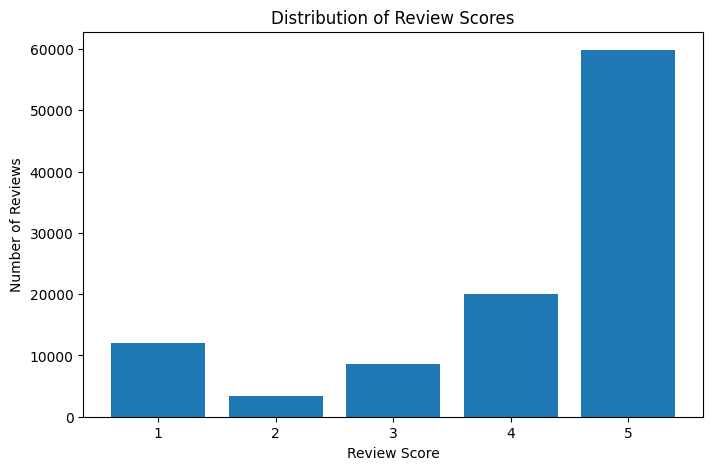

In [51]:
plt.figure(figsize=(8, 5))
review_counts = df_main["review_score"].value_counts().sort_index()
plt.bar(review_counts.index, review_counts.values)
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Scores")
plt.xticks(review_counts.index) # Ensure all review scores are shown on x-axis
plt.show()

Text(0.5, 1.0, 'Top 10 Product Categories')

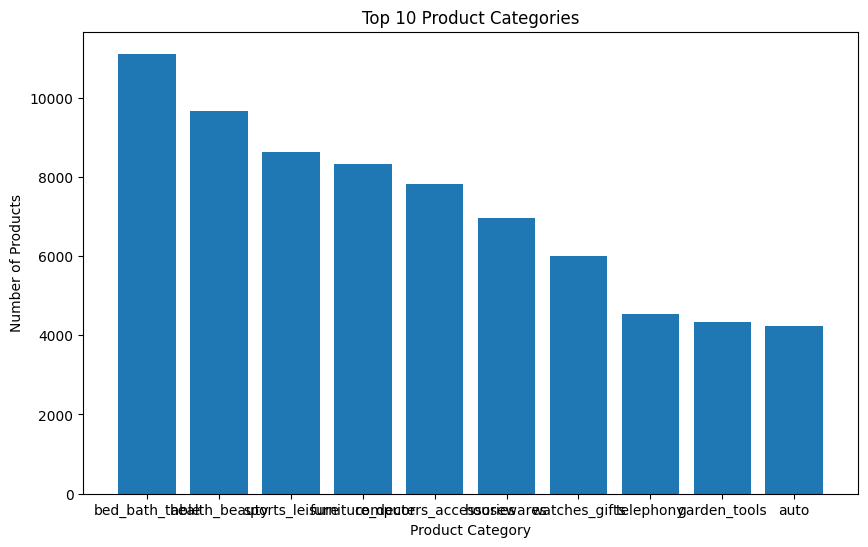

In [52]:
plt.figure(figsize=(10, 6))
product_counts = df_products["product_category_name_english"].value_counts().head(10)
plt.bar(product_counts.index, product_counts.values)
plt.xlabel("Product Category")
plt.ylabel("Number of Products")
plt.title("Top 10 Product Categories")

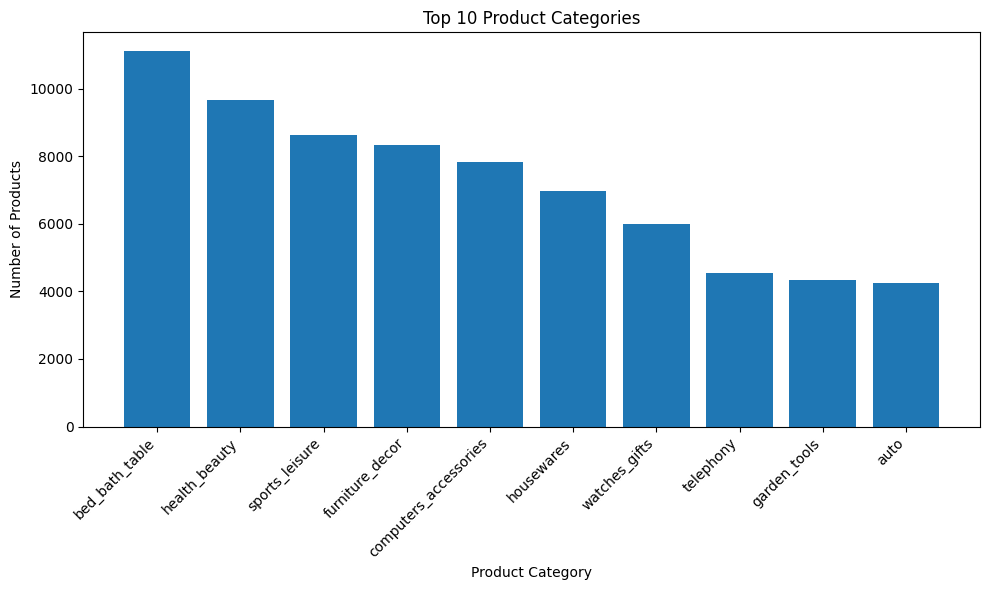

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

product_counts = df_products["product_category_name_english"].value_counts().head(10)

plt.bar(product_counts.index, product_counts.values)

plt.xlabel("Product Category")
plt.ylabel("Number of Products")
plt.title("Top 10 Product Categories")

plt.xticks(rotation=45, ha='right')  # ✅ FIX LABEL OVERLAP

plt.tight_layout()  # ✅ prevents cutting edges

plt.savefig("top 10 products.png", dpi=300, bbox_inches="tight")


plt.show()

In [54]:
delayed = df_main[df_main["delivery_delay"] > 0]["review_score"]
on_time = df_main[df_main["delivery_delay"] <= 0]["review_score"]

In [55]:
from scipy.stats import ttest_ind

ttest_ind(delayed.dropna(), on_time.dropna())

TtestResult(statistic=np.float64(-134.5434029292726), pvalue=np.float64(0.0), df=np.float64(100646.0))

In [56]:
credit = df_main[df_main["payment_type"] == "credit_card"]["payment_value"]
cash = df_main[df_main["payment_type"] == "boleto"]["payment_value"]

In [57]:
ttest_ind(credit.dropna(), cash.dropna())

TtestResult(statistic=np.float64(10.38031150152542), pvalue=np.float64(3.141931466159568e-25), df=np.float64(97106.0))

In [58]:
!apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic
!jupyter nbconvert --to pdf your_notebook.ipynb

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-extra texlive-latex-recommended texlive-pictures tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf libavalon-framework-java
  libcommons-logging-java-doc libexcalibur-logkit-java 